In [1]:
import sys 
import numpy as np
import matplotlib.pyplot as plt
from collections.abc import Sequence, Callable

sys.path.append("../")

from oxels.analytical_benchmark import TwoShapes
from oxels.datasets import OxelDataset
from oxels.analytical_benchmark import TwoShapes

AttributeError: 'TwoShapes' object has no attribute 'n_types'

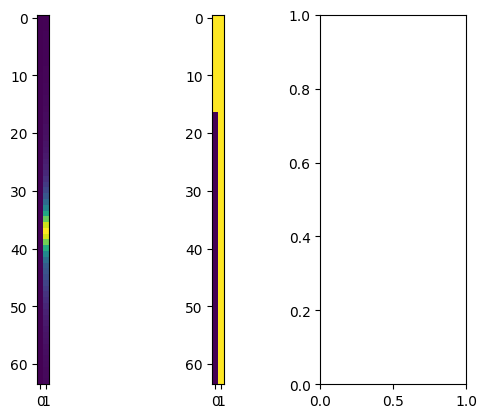

In [2]:
cs = [np.array([-0.25,-0.25]), np.array([0.25,0.25]), np.array([-0.25,0.25])]
as_ = np.random.random(3)*2*np.pi
Ms = np.array([[[np.cos(a), np.sin(a)],[-np.sin(a), np.cos(a)]] for a in as_])
Ms += np.random.normal(0,0.2,Ms.shape)
types = [1,1,0]
#plt.imshow(get_pattern(cs, Ms, types, np.array([0.0,0]), 1.5*np.array([[0.8,-0.6],[0.6,0.8]])))

ts = TwoShapes(2)
a = 0.3
plt.subplot(131)
params = (cs, Ms, types, np.array([0.5,0]), np.array([[np.cos(a), np.sin(a)],[-np.sin(a), np.cos(a)]]))
plt.imshow(ts.get_image(*params))
plt.subplot(132)
local_Rs, local_As, local_types = ts.get_polar_coordinates(*params)
plt.imshow(local_types)
plt.subplot(133)

oxels = ts.get_encoded_coordinates(*params, n_bits_dist=3, n_bits_angle=3, max_dist=1)
#plt.imshow(oxels[:,:,1:4])
plt.imshow(oxels[:,:,[0,1,-1]])

In [ ]:



class AnalyticalDataset(OxelDataset):
    def __init__(self,
                 n_samples: int,
                 augmentation: Callable,
                 w,
                 h,
                 frac_keep=0.125,
                 max_dxy=0.5,
                 max_scale=0.4,
                 max_skew=0.2,
                 noise=0.05):
        
        super().__init__([None]*n_samples, augmentation) #we're not using files
        self.two_shapes = TwoShapes(w, h)
        self.w, self.h = w,h
        self.frac_keep = frac_keep
        self.max_dxy = max_dxy
        self.max_scale = max_scale
        self.max_skew = max_skew
        self.noise = noise

        self.X, self.Y = np.meshgrid(np.linspace(-1,1,w),np.linspace(-1,1,h))

    def _get_indices(self, c1, c2, M):
        XA = c2[0] + M[0,0]*(self.X + c1[0]) + M[0,1]*(self.Y + c1[1])
        YA = c2[1] + M[1,0]*(X + self.c1[0]) + M[1,1]*(self.Y + c1[1])

        XA = np.round(0.5*(self.w-1)*XA + 0.5*(self.w-1)).astype(int)
        YA = np.round(0.5*(self.h-1)*YA + 0.5*(self.h-1)).astype(int)

        YR = np.random.randint(0,self.h,(self.h,self.w))
        XR = np.random.randint(0,self.w,(self.h,self.w))

        mask = (XA >= 0)*(XA < self.w)*(YA >= 0)*(YA < self.h)
        mask *= np.random.random(mask.shape) < self.frac_keep
        indices = ((YA*self.w + XA)*mask + (YR*self.w + XR)*(1-mask)).ravel()
        return indices, mask.ravel()

    def _get_data(self, file: str) -> Sequence[np.ndarray]:
        """
        Returns

        Parameters
        ----------
        file : ignored
        
        Returns
        -------
        view1   : ndarray, shape (H, W, 3), dtype=float
            First view
        view2   : ndarray, shape (H, W, 3), dtype=float
            Second view
        indices : ndarray, shape (H*W), dtype=int
            Indices from 0 to H*W-1 of view2.
        flags   : ndarray, shape (H*W), dtype=bool
            Flags to that indicate correct matches between view1 and transformed view2:
            flags[i] is true if view2[indices[i]//W, indices[i]%W] is (nearly) the same as view1[i//w, i%w]
        mask1   : ndarray, shape (H, W), dtype=bool
            Which pixels of view1 should be used for loss computation
        mask2   : ndarray, shape (H, W), dtype=bool
            Which pixels of view2 should be used for loss computation
        """
        
        sub_input = np.zeros((2, h, w, 1), dtype=np.float32)
        sub_output = np.zeros((2, w*h), dtype=np.int32)

        K = np.random.randint(3,5)
        types = np.random.randint(0,2,K)
        Ms = np.zeros((K,2,2))
        cs = np.zeros((K,2))

        for i in range(K):
            M = np.diag(1 + (np.random.random(2) - 0.5)*self.max_scale)
            M[1,0] = M[0,1] = (np.random.random() - 0.5)*self.max_skew
            a = np.random.random()*2*np.pi
            Ms[i] = M.dot([[np.cos(a), - np.sin(a)], [np.sin(a), np.cos(a)]])

            a = 2*i*np.pi/K + (np.random.random() - 0.5)*0.4*np.pi
            cs[i] = np.dot([[np.cos(a), - np.sin(a)], [np.sin(a), np.cos(a)]], [0, 0.25 + np.random.random()*0.5])
        
        cgs = np.zeros((2,2))
        Mgs = np.zeros((2,2,2))
        views = []
        for j in range(2):
            cgs[j] = (np.random.random(2) - 0.5)*self.max_dxy
            Mg = np.diag(1 + (np.random.random(2) - 0.5)*self.max_scale)
            Mg[1,0] = Mg[0,1] = (np.random.random() - 0.5)*self.max_skew
            a = np.random.random()*2*np.pi
            Mgs[j] = Mg.dot([[np.cos(a), - np.sin(a)], [np.sin(a), np.cos(a)]])

            views.append(self.two_shapes.get_image(cs, Ms, types, cgs[j], Mgs[j]))
            views[-1] += np.random.normal(0, self.noise, (self.h, self.w))

        indices, flags = self.get_indices(-cgs[0], cgs[1], Mgs[1].dot(np.linalg.inv(Mgs[0])))
        mask = np.ones(flags.shape, dtype=bool)

        return views[0], views[1], indices, flags, mask, mask

ModuleNotFoundError: No module named 'oxels'